<a href="https://colab.research.google.com/github/navadeepsaran/AIML_project_and_labs/blob/main/AIML_Module_3_Lab_2_Implementing_KNN_from_scratch_and_visualize_Algorithm_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
### MODULE 3: CLASSIFICATION-1
### LAB-2 : Implementing KNN from scratch and visualize Algorithm performance

---

# **Section 1: Implementing KNN**

In the last lab we had started discussing about KNN or K Nearest Neighbour method for clasification. We used the pre-built scikit-learn library for KNN. Now let's see how to implement this algorithm from scratch  

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from collections import Counter

In [2]:
def predict(X_train, y_train, X_test, k):
    distances = []
    targets = []

    for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

    distances = sorted(distances)

    for i in range(k):
        index = distances[i][1]
        targets.append(y_train[index])

    # return most common target
    return Counter(targets).most_common(1)[0][0]

In [3]:
def k_nearest_neighbor(X_train, y_train, X_test, k):

    assert k <= len(X_train), "[!] K cannot be larger than number of samples."

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.asarray(predictions)

**Note** : If k = 1 then the algorithm will simply return the label of the nearest neighbour. When we give k > 1 the most common label out of the given labels in the k neighbours will be selected.The code for 1 NN is given as follows and does not have to be so complicated.

In [4]:
def NN1(traindata, trainlabel, query):
  diff  = traindata - query  # find the difference between features. Numpy automatically takes care of the size here
  sq = diff*diff # square the differences
  dist = sq.sum(1) # add up the squares
  label = trainlabel[np.argmin(dist)] # our predicted label is the label of the training data which has the least distance from the query
  return label

Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm.

In [5]:
def Accuracy(gtlabel, predlabel):
  assert len(gtlabel)==len(predlabel), "Length of the groundtruth labels and predicted labels should be the same"
  correct = (gtlabel==predlabel).sum() # count the number of times the groundtruth label is equal to the predicted label.
  return correct/len(gtlabel)

## Section 1.1 - Iris Dataset
Let's try it out on Iris Dataset present in the scikit learn library

In [6]:
from sklearn.datasets import load_iris

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)

df["target"] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
X = np.array(df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']])
y = np.array(df['target'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=17)

In [8]:
# Making our predictions
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

# evaluating accuracy
accuracy = Accuracy(y_test, predictions)
print("The accuracy of our classifier is {} %".format(100*accuracy))

The accuracy of our classifier is 94.0 %


Voila! You have implemented your own version of the K-Nearest Neighbours algorithm, which works very well on the Iris Dataset. Congratulations!  

Now try out the sklearn implementation and compare your results.  

In [9]:
from sklearn.neighbors import KNeighborsClassifier

sklearn_knn = KNeighborsClassifier(n_neighbors=7)
sklearn_knn.fit(X_train,y_train)
sklearn_predictions = sklearn_knn.predict(X_test)
accuracy = accuracy_score(y_test, sklearn_predictions)
print("The accuracy of Sklearn classifier is {} %".format(100*accuracy))

The accuracy of Sklearn classifier is 94.0 %


##  Section 1.2: Weighted NN
For KNN, If k is too small, the algorithm would be more sensitive to outliers. If k is too large, then the neighborhood may include too many points from other classes. We also take the label with max votes in the neighbourhood. Another choice can be that instead of giving equal weights to each of the neighbours we can give weighted points in the neighbourhood. So we weigh points by the inverse of their distance. Therefore, closer points will be given a higher priority as compared to the far off points.

An easy way to implement this is by specifying the 'weights' parameter as distance when defining the sklearn KNN function. For more information go through this [site](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [10]:
## TASK
## Modify the KNN function you wrote to return all the K-nearest neighbours along with their distances,
## instead of just the output that was most common. You don't need to find out accuracy, just modify the function
## and return the k-nearest neighbours and distances.

In [11]:
# TASK — Section 1.2: Modified KNN to return k-nearest neighbours and their distances

def predict_with_distances(X_train, y_train, X_test_point, k):
    """
    Returns the k nearest neighbours and their distances from the test point.

    Parameters:
    X_train     : Training data
    y_train     : Training labels
    X_test_point: A single test data point
    k           : Number of neighbours

    Returns:
    k_neighbours : List of (distance, label) for each of the k nearest neighbours
    """
    distances = []

    # Compute L2 (Euclidean) distance from the test point to every training point
    for i in range(len(X_train)):
        dist = np.sqrt(np.sum(np.square(X_test_point - X_train[i, :])))
        distances.append((dist, y_train[i]))  # store (distance, label)

    # Sort by distance (ascending)
    distances = sorted(distances, key=lambda x: x[0])

    # Return only the k nearest
    k_neighbours = distances[:k]
    return k_neighbours


# --- Test it on the Iris dataset ---
# Pick the first test point
sample_point = X_test[0]

k = 7
neighbours = predict_with_distances(X_train, y_train, sample_point, k)

print(f"Test point: {sample_point}")
print(f"\nThe {k} nearest neighbours (distance, label):")
for i, (dist, label) in enumerate(neighbours):
    print(f"  Neighbour {i+1}: Distance = {dist:.4f}, Label = {label} ({data.target_names[label]})")

Test point: [5.4 3.9 1.3 0.4]

The 7 nearest neighbours (distance, label):
  Neighbour 1: Distance = 0.3464, Label = 0 (setosa)
  Neighbour 2: Distance = 0.3873, Label = 0 (setosa)
  Neighbour 3: Distance = 0.4123, Label = 0 (setosa)
  Neighbour 4: Distance = 0.4583, Label = 0 (setosa)
  Neighbour 5: Distance = 0.4583, Label = 0 (setosa)
  Neighbour 6: Distance = 0.4690, Label = 0 (setosa)
  Neighbour 7: Distance = 0.4796, Label = 0 (setosa)


# **Section 2: Visualizing Data**  

We will look into something called **Voronoi** diagrams.  

**Note**: Ideally, we should perform data visualization to see what the data looks like before we apply any Machine Learning algorithm.  Only for the purpose of this lab session, we're explaining it after you've applied KNN.

### Voronoi Diagrams  

In simple terms, Voronoi diagrams help you to visualize the dataset by partioning the plane into regions that are close to a given set of points. These regions are also called Voronoi cells.  

Note that the cells/regions depend on the Distance metric being used. One way of interpreting this is by understanding that the distance metric decides the degree to which a 'point' or 'seed' in the Voronoi diagram has influence.  For each seed there is a corresponding region, called a Voronoi cell, consisting of all points of the plane closer to that seed than to any other.

This [link](https://en.wikipedia.org/wiki/Voronoi_diagram#Illustration) provides a wonderful illustration of Voronoi plots for 20 points in two cases: (1) Using Euclidean distance, and (2) Using Manhattan distance.  



Since our Iris data is 4-dimensional (as it has 4 attributes), we need to convert into a form that can be represented in 2-D.   

While there are methods to visualize data higher than 2-dimensions, that is beyond scope for now.  

For simplicity, we just take the first two columns of the iris dataset attributes and observe the Voronoi diagram generated for that.  
Alternatively, one can also perform PCA (Principal Component Analysis), to reduce the 4D data to just two dimensions.

In [38]:
#@title Plotting Voronoi regions
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite voronoi regions in a 2D diagram to finite
    regions.

    Parameters
    ----------
    vor : Voronoi
        Input diagram
    radius : float, optional
        Distance to 'points at infinity'.

    Returns
    -------
    regions : list of tuples
        Indices of vertices in each revised Voronoi regions.
    vertices : list of tuples
        Coordinates for revised Voronoi vertices. Same as coordinates
        of input vertices, with 'points at infinity' appended to the
        end.

    """

    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points, axis=0).max()

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # *** FIX START ***
        # Handle cases where a point might not have any ridges (e.g., due to degeneracies)
        # If p1 is not in all_ridges, we cannot reconstruct its non-finite region.
        # In such cases, we skip this point to prevent KeyError.
        if p1 not in all_ridges:
            continue
        # *** FIX END ***

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                # finite ridge: already in the region
                continue

            # Compute the missing endpoint of an infinite ridge

            t = vor.points[p2] - vor.points[p1] # tangent
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])  # normal

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:,1] - c[1], vs[:,0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        # finish
        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

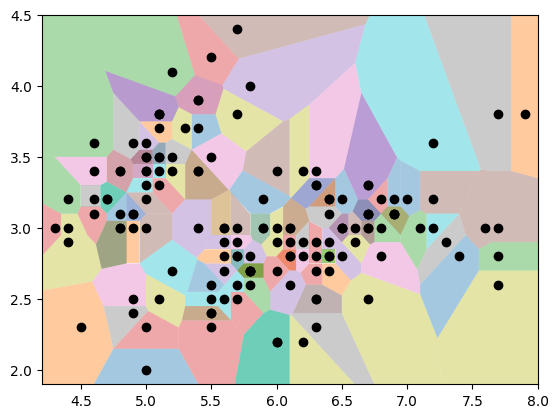

In [13]:
## Plotting Voronoi regions for the Iris dataset

points = []
xpts = np.array(df['sepal length (cm)'])
ypts = np.array(df['sepal width (cm)'])
for i in range(len(xpts)):
  points.append([xpts[i],ypts[i]])
# print(points)
points = np.array(points)
# compute Voronoi tesselation
vor = Voronoi(points)

regions,vertices = voronoi_finite_polygons_2d(vor)

for region in regions:
    polygon = vertices[region]
    plt.fill(*zip(*polygon), alpha=0.4)

plt.plot(points[:,0], points[:,1], 'ko')
plt.xlim(vor.min_bound[0] - 0.1, vor.max_bound[0] + 0.1)
plt.ylim(vor.min_bound[1] - 0.1, vor.max_bound[1] + 0.1)

plt.show()

## Section 2.2: Understanding Decision Boundaries  
So you have seen the Voronoi diagram of the dataset, implemented KNN, and also seen your algorithm's performance in terms of accuracy? Impressive!  
Wouldn't it also be great to know how exactly these 'votes' or neighbours are decided through some kind of visualization?  


### Decision Boundary

While the Voronoi diagram gave us a good idea of the points present in our dataset, to understand how KNN performed on our dataset we can plot decision boundaries. Decision boundaries, as the name suggests, divide the plane into different regions of classification.  

Note that here again, for simplicity, we have only considered first two attributes of the DataFrame (ie, Sepal Length and Sepal Width).  

In [14]:
from matplotlib.colors import ListedColormap
import seaborn as sns


def decision_boundary_plot(x_dec,y_dec,k):
  h = .02  # step size in the mesh

  # Create color maps
  n = len(set(y_dec))
  cmap_light = ListedColormap(['pink', 'green', 'cyan','yellow'][:n])
  cmap_bold = ['pink', 'darkgreen', 'blue','yellow'][:n]

  for weights in ['uniform', 'distance']:
      # we create an instance of Neighbours Classifier and fit the data.
      clf = KNeighborsClassifier(n_neighbors=k, weights=weights)
      clf.fit(x_dec, y_dec)

      # Plot the decision boundary. For that, we will assign a color to each
      # point in the mesh [x_min, x_max]x[y_min, y_max].
      x_min, x_max = x_dec[:, 0].min() - 1, x_dec[:, 0].max() + 1
      y_min, y_max = x_dec[:, 1].min() - 1, x_dec[:, 1].max() + 1
      xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
      Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

      # Put the result into a color plot
      Z = Z.reshape(xx.shape)
      plt.figure(figsize=(8, 6))
      plt.contourf(xx, yy, Z, cmap=cmap_light)

      # Plot also the training points
      sns.scatterplot(x=x_dec[:, 0], y=x_dec[:, 1], hue=y_dec,
                      palette=cmap_bold, alpha=1.0, edgecolor="black")
      plt.xlim(xx.min(), xx.max())
      plt.ylim(yy.min(), yy.max())
      plt.title("Multi-Classification (k = %i, weights = '%s')"% (k, weights))

  plt.show()


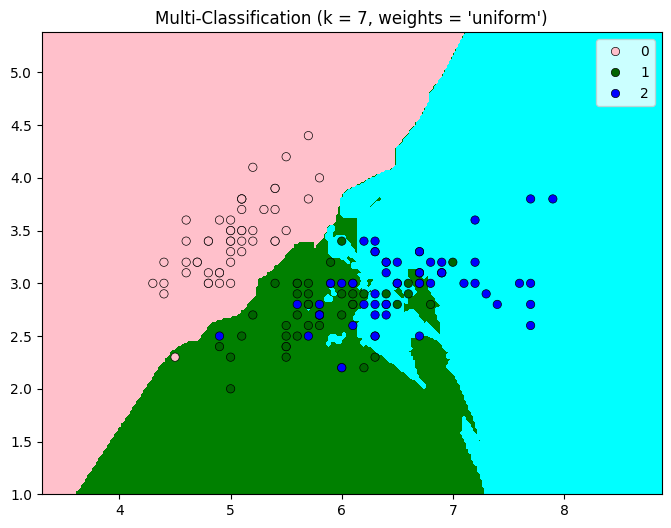

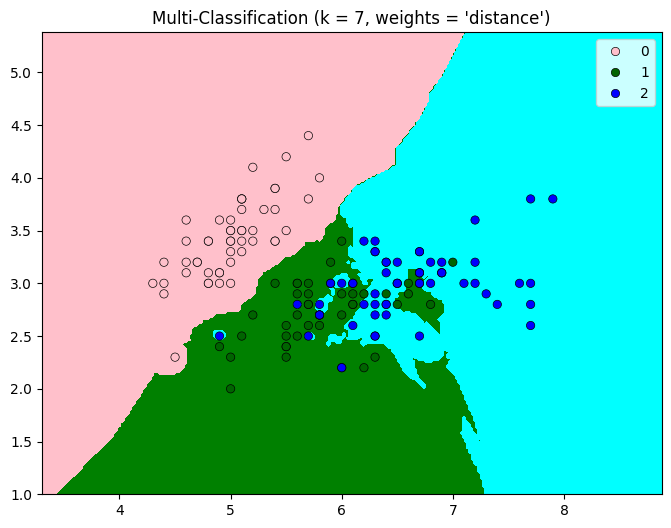

In [15]:
x_pts = X[:,:2]
y_pts = y
decision_boundary_plot(x_pts,y_pts,7)

In [16]:
## TASK-2
## In the above cells, we saw the Voronoi diagram of the data and plotted the KNN decision boundaries
## by only considering two attributes of the dataset. You must be already familiar with PCA.
## Apply PCA on the dataset above to reduce it to two dimensions.
## Plot the Voronoi diagram and Decision boundaries after that.

Original shape: (150, 4)
After PCA: (150, 2)
Variance explained by 2 PCs: 97.77%


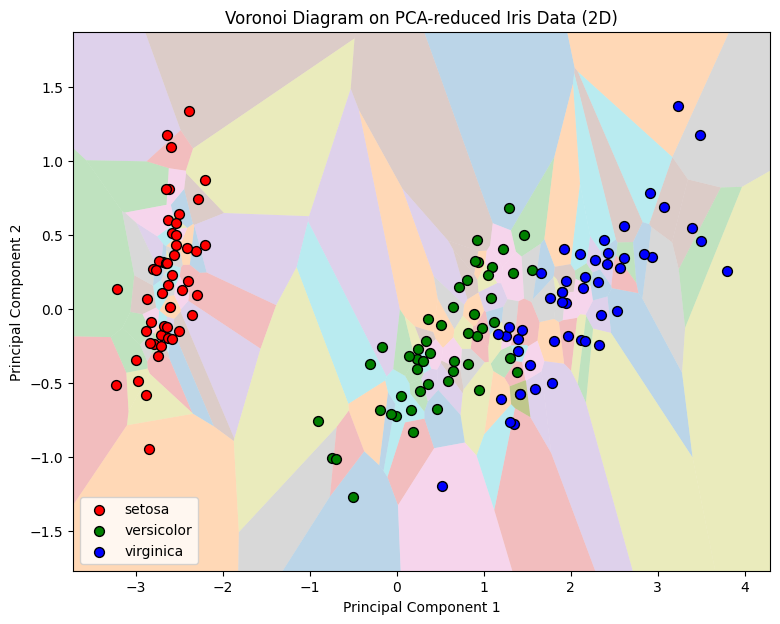

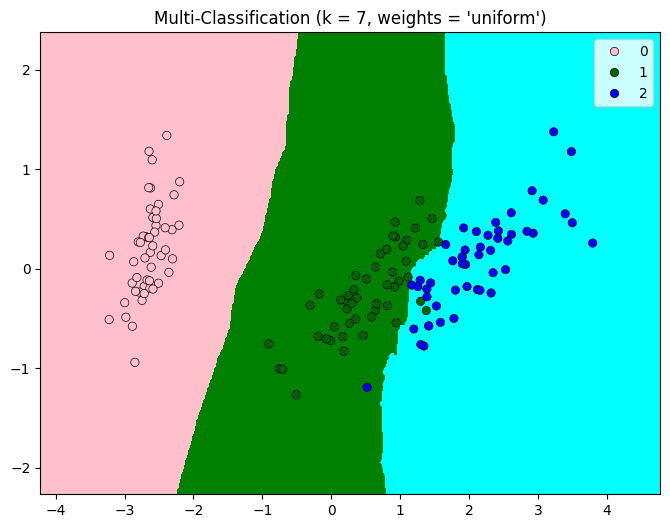

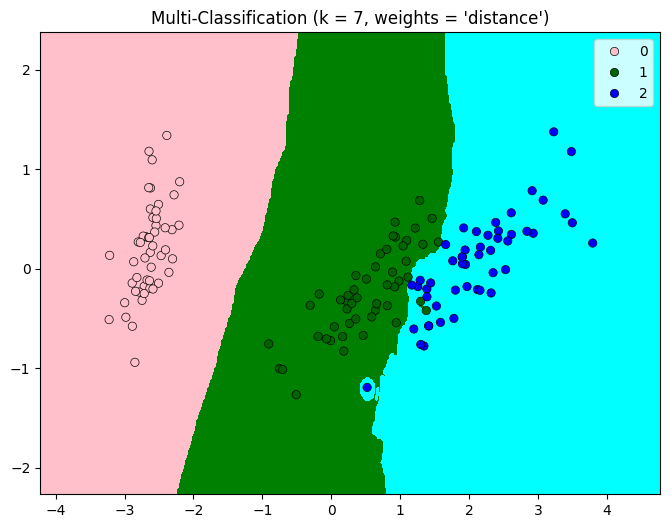

<Figure size 640x480 with 0 Axes>

In [17]:
# TASK-2: Apply PCA to reduce Iris data to 2D, then plot Voronoi and Decision Boundaries

from sklearn.decomposition import PCA

# ----- Step 1: Apply PCA -----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # X is the full 4-feature Iris data

print("Original shape:", X.shape)
print("After PCA:", X_pca.shape)
print(f"Variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ----- Step 2: Voronoi Diagram on PCA data -----
pca_points = X_pca  # shape (150, 2)

vor_pca = Voronoi(pca_points)
regions_pca, vertices_pca = voronoi_finite_polygons_2d(vor_pca)

plt.figure(figsize=(9, 7))
colors = ['red', 'green', 'blue']
for region in regions_pca:
    polygon = vertices_pca[region]
    plt.fill(*zip(*polygon), alpha=0.3)

# Overlay the actual points, colored by class
for cls in range(3):
    mask = (y == cls)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cls], label=data.target_names[cls],
                edgecolors='k', s=50, zorder=5)

plt.xlim(vor_pca.min_bound[0] - 0.5, vor_pca.max_bound[0] + 0.5)
plt.ylim(vor_pca.min_bound[1] - 0.5, vor_pca.max_bound[1] + 0.5)
plt.title("Voronoi Diagram on PCA-reduced Iris Data (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# ----- Step 3: Decision Boundary on PCA data -----
decision_boundary_plot(X_pca, y, k=7)
plt.suptitle("KNN Decision Boundary on PCA-reduced Iris Data", y=1.02)
plt.show()

## Section 2.3: Confusion Matrix  
In classification problems, a confusion matrix, also known as an error matrix, is a table that allows visualization of the performance of an algorithm, typically a supervised learning one. Each row of the matrix represents the instances in an actual class while each column represents the instances in a predicted class.

In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
# print(confusion_matrix(y_test,predictions))
pd.crosstab(y_test, predictions, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,2,All
True,,,,
0,13,0,0,13
1,0,22,0,22
2,0,3,12,15
All,13,25,12,50


Text(0.5, 23.52222222222222, 'Predicted label')

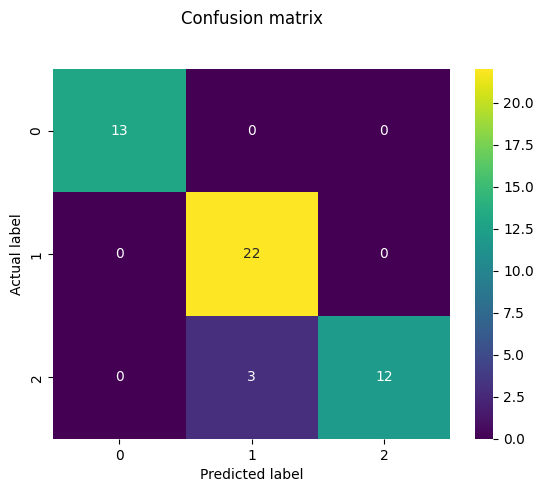

In [20]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, predictions)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="viridis" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

## Section 2.4: Classification Report

Precision, Recall, and F1-Score are other metrics besides accuracy that one might look for in an algorithm.  Depending on the use-case, one might consider one metric more important than the other.  

Note: *T-> True, F->False, P->Positive, N->Negative*
    
Mathematically, Accuracy is :  

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$  

**Precision**: The accuracy of positive predictions


$Precision = \frac{TP}{TP+FP}$

**Recall**:Fraction of positives that were correctly identified


$Recall = \frac{TP}{TP+FN}$


**F1-score**: Harmonic mean of precision and recall  


$F1 = \frac{2*Precision*Recall}{Precision+Recall} = \frac{2*TP}{2*TP+FP+FN}$  



In [21]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.88      1.00      0.94        22
           2       1.00      0.80      0.89        15

    accuracy                           0.94        50
   macro avg       0.96      0.93      0.94        50
weighted avg       0.95      0.94      0.94        50



### **Car Evaluation Dataset**

In [22]:
# Upload the Car evaluation data CSV file that has been shared with you.
# Run this cell, click on the 'Choose files' button and upload the file.
from google.colab import files
uploaded = files.upload()

Saving car_evaluation.csv to car_evaluation.csv


In [23]:
car_df = pd.read_csv(list(uploaded.keys())[0])
car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [24]:
for x in car_df.columns:
  # print(x)
  le = preprocessing.LabelEncoder()
  le.fit(car_df[x])
  car_df[x]=le.transform(car_df[x])

car_df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,3,3,0,0,2,2,2
1,3,3,0,0,2,0,2
2,3,3,0,0,1,1,2
3,3,3,0,0,1,2,2
4,3,3,0,0,1,0,2
...,...,...,...,...,...,...,...
1722,1,1,3,2,1,2,1
1723,1,1,3,2,1,0,3
1724,1,1,3,2,0,1,2
1725,1,1,3,2,0,2,1


In [25]:
dataset = car_df.values
X = dataset[:,0:6]
y = np.array(dataset[:,6])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)

In [26]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
score = accuracy_score(y_test, predictions)
print("The accuracy of the classifier on Car evaluation dataset is {:.2f} %".format(100*score))

The accuracy of the classifier on Car evaluation dataset is 89.88 %


In [27]:
## TASK-3
## Plot a Confusion Matrix for the results of the Car evaluation dataset

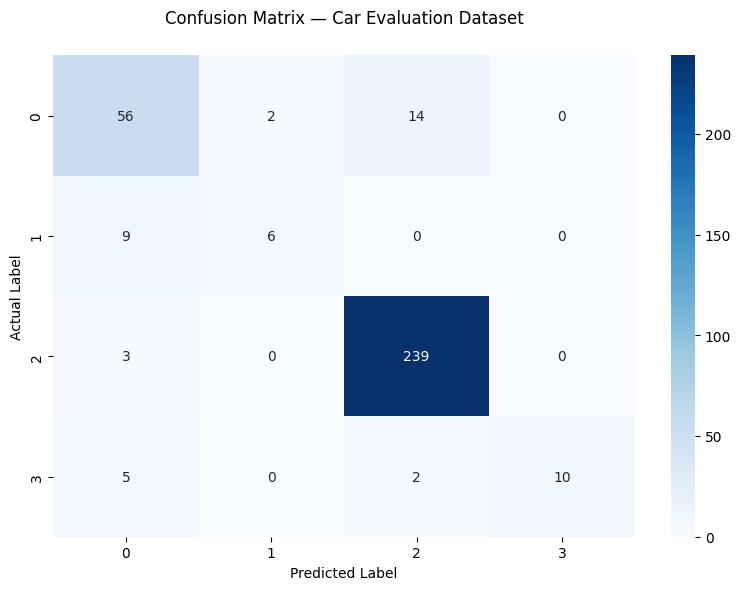


Cross-tabulation:
Predicted   0  1    2   3  All
True                          
0          56  2   14   0   72
1           9  6    0   0   15
2           3  0  239   0  242
3           5  0    2  10   17
All        73  8  255  10  346


In [28]:
# TASK-3: Confusion Matrix for Car Evaluation Dataset

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cnf_matrix_car = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
p = sns.heatmap(pd.DataFrame(cnf_matrix_car), annot=True, cmap="Blues", fmt='g')
plt.title('Confusion Matrix — Car Evaluation Dataset', y=1.05)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Also show as cross-tab for readability
print("\nCross-tabulation:")
print(pd.crosstab(y_test, predictions, rownames=['True'], colnames=['Predicted'], margins=True))

In [29]:
## TASK-4
## Print a Classification Report for the results of the Car evaluation dataset

In [30]:
# TASK-4: Classification Report for Car Evaluation Dataset

from sklearn.metrics import classification_report

print("Classification Report — Car Evaluation Dataset")
print("=" * 55)
print(classification_report(y_test, predictions))

Classification Report — Car Evaluation Dataset
              precision    recall  f1-score   support

           0       0.77      0.78      0.77        72
           1       0.75      0.40      0.52        15
           2       0.94      0.99      0.96       242
           3       1.00      0.59      0.74        17

    accuracy                           0.90       346
   macro avg       0.86      0.69      0.75       346
weighted avg       0.90      0.90      0.89       346



In [31]:
## TASK-5
## Plot the Decision boundary diagram for the classifier of the Car evaluation dataset

Variance explained by 2 PCs: 43.52%


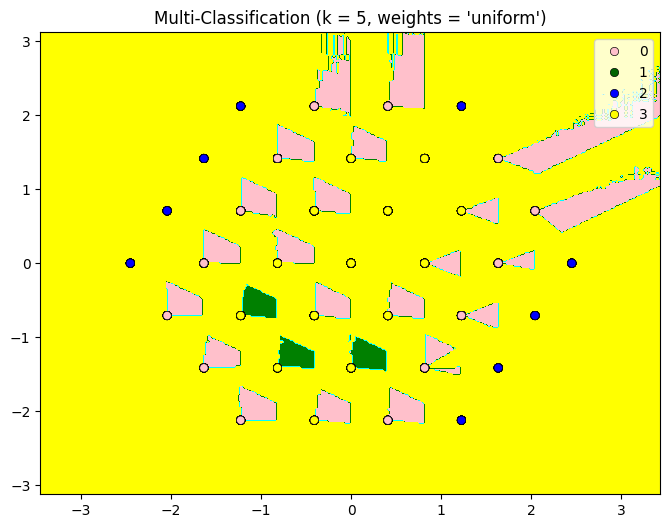

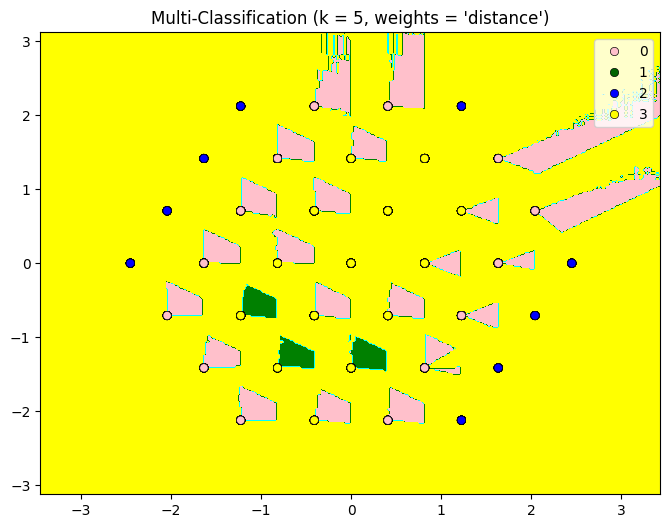

<Figure size 640x480 with 0 Axes>

In [32]:
# TASK-5: Decision Boundary for Car Evaluation Dataset
# Car dataset has 6 features — we reduce to 2D using PCA first

from sklearn.decomposition import PCA

# Re-fetch dataset arrays (they were set globally above)
dataset_car = car_df.values
X_car = dataset_car[:, 0:6]
y_car = np.array(dataset_car[:, 6])

# Reduce to 2D with PCA
pca_car = PCA(n_components=2)
X_car_2d = pca_car.fit_transform(X_car)

print("Variance explained by 2 PCs:",
      f"{pca_car.explained_variance_ratio_.sum()*100:.2f}%")

# Plot decision boundary using the 2D PCA data
decision_boundary_plot(X_car_2d, y_car, k=5)
plt.suptitle("KNN Decision Boundary — Car Evaluation Dataset (PCA 2D)", y=1.02)
plt.show()

In [33]:
## TASK-6
## Plot the Voronoi diagram for the classifier of the Car evaluation dataset

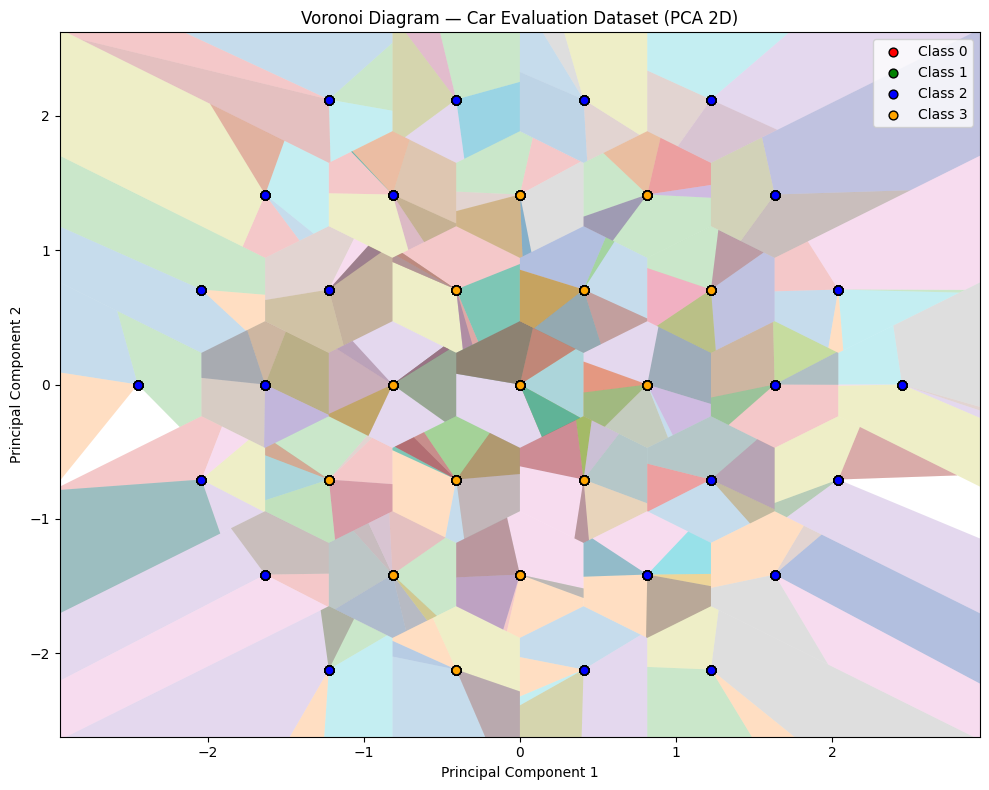

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi

# Assuming voronoi_finite_polygons_2d is defined in an earlier cell or imported
# (It is present in ZNOPcS3f7sZg)

# TASK-6: Voronoi Diagram for Car Evaluation Dataset (using PCA 2D)

# X_car_2d and y_car already computed in TASK-5
# (Run TASK-5 cell first if you haven't already)

# --- Fix for KeyError: Remove duplicate points from X_car_2d for Voronoi computation ---
# Find unique rows in X_car_2d and get their original indices
# Using axis=0 to treat rows as elements for uniqueness
unique_points_pca, unique_indices_pca = np.unique(X_car_2d, axis=0, return_index=True)

# Add a very small amount of random noise (jitter) to break potential numerical degeneracies
# that can cause issues for Voronoi diagram computation, leading to KeyError.
jitter = np.random.normal(0, 1e-9, unique_points_pca.shape)
perturbed_unique_points_pca = unique_points_pca + jitter

# Create the Voronoi object using the perturbed unique points
vor_car = Voronoi(perturbed_unique_points_pca)
regions_car, vertices_car = voronoi_finite_polygons_2d(vor_car)

# Color map for 4 car classes: unacc, acc, good, vgood
car_colors = ['red', 'green', 'blue', 'orange']
# `unique_classes` should still be based on the original `y_car` for correct labeling
unique_classes = sorted(np.unique(y_car))

plt.figure(figsize=(10, 8))

# Fill Voronoi cells (regions are based on unique points)
for region in regions_car:
    polygon = vertices_car[region]
    plt.fill(*zip(*polygon), alpha=0.25)

# Scatter points colored by class (using original X_car_2d and y_car)
for idx, cls in enumerate(unique_classes):
    # This mask now correctly applies to the original full dataset
    mask = (y_car == cls)
    plt.scatter(X_car_2d[mask, 0], X_car_2d[mask, 1],
                c=car_colors[idx % len(car_colors)],
                label=f'Class {cls}',
                edgecolors='k', s=40, zorder=5)

plt.xlim(vor_car.min_bound[0] - 0.5, vor_car.max_bound[0] + 0.5)
plt.ylim(vor_car.min_bound[1] - 0.5, vor_car.max_bound[1] + 0.5)
plt.title("Voronoi Diagram — Car Evaluation Dataset (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

## **Homework Assignment: Exploring Distance Metrics and KNN**

---

### **Problem 1: Implementing Custom Distance Metrics**

In this exercise, you'll implement distance metrics from scratch to deepen your understanding.

**Task 1.1:** Implement the Minkowski distance formula without using any library functions (except basic numpy operations).

Recall that Minkowski distance is defined as:

$$d(x, x') = \left(\sum_{j=1}^{D} |x_j - x'_j|^p\right)^{1/p}$$

where $p$ is a parameter. When $p=1$, it's Manhattan distance, and when $p=2$, it's Euclidean distance.

In [40]:
## HOMEWORK TASK 1.1
## Implement the Minkowski distance function below
## Test it with p=1 (should match Manhattan) and p=2 (should match Euclidean)
## Expected number of lines: 3-5


# HOMEWORK TASK 1.1 — Minkowski Distance from scratch

from scipy.spatial import distance  # needed for verification

def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.

    Parameters:
    x1, x2: numpy arrays representing points
    p: the order of the Minkowski distance

    Returns:
    float: the Minkowski distance
    """
    # Step 1: Absolute differences
    diff = np.abs(x1 - x2)
    # Step 2: Raise each to power p and sum
    total = np.sum(diff ** p)
    # Step 3: Take the p-th root
    return total ** (1.0 / p)


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:      ", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:      ", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance:       12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance:       7.0710678118654755


---

### **Problem 2: Visualizing Decision Boundaries**

Understanding how KNN makes predictions is crucial. In this exercise, you'll visualize decision boundaries for different values of K.

**Task 2.1:** Create a function that visualizes the decision boundary of a KNN classifier on 2D data.

**Hint:** You'll need to:
1. Create a mesh grid covering the feature space
2. Train a KNN classifier
3. Predict the class for each point in the mesh
4. Plot the results using `plt.contourf()` for the decision boundary
5. Overlay the training data points

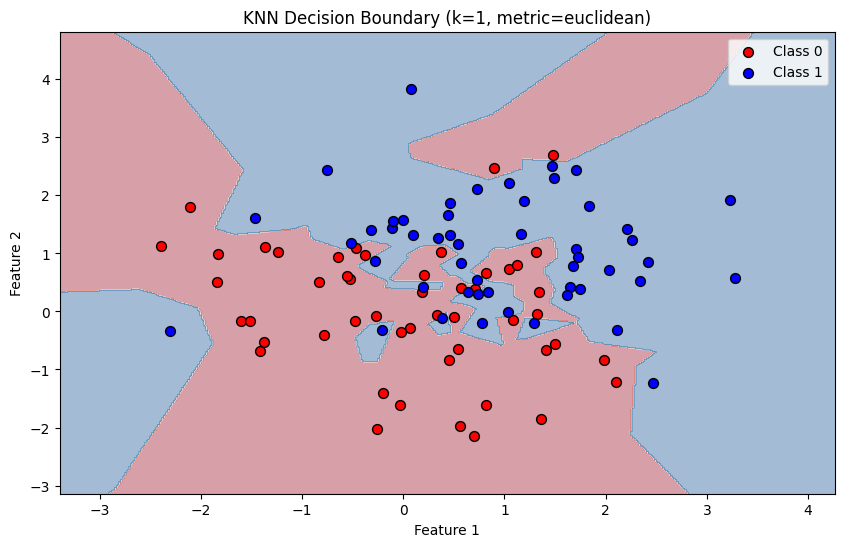

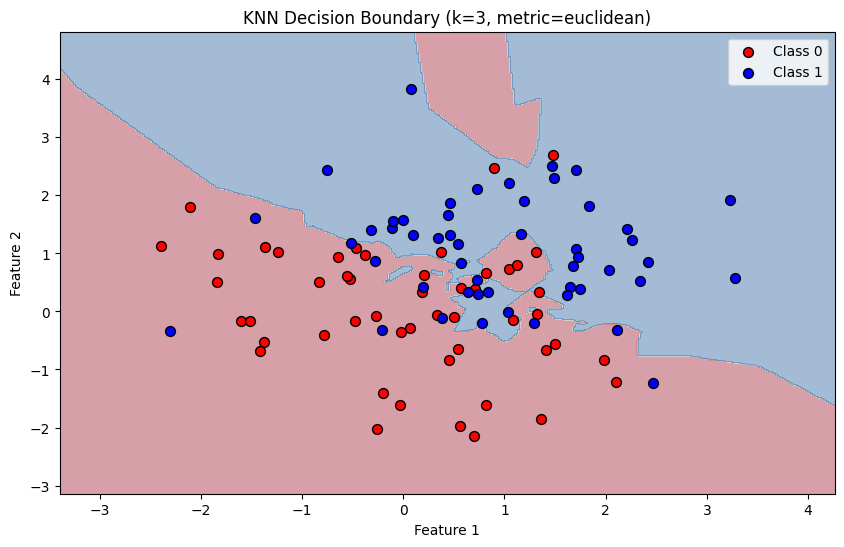

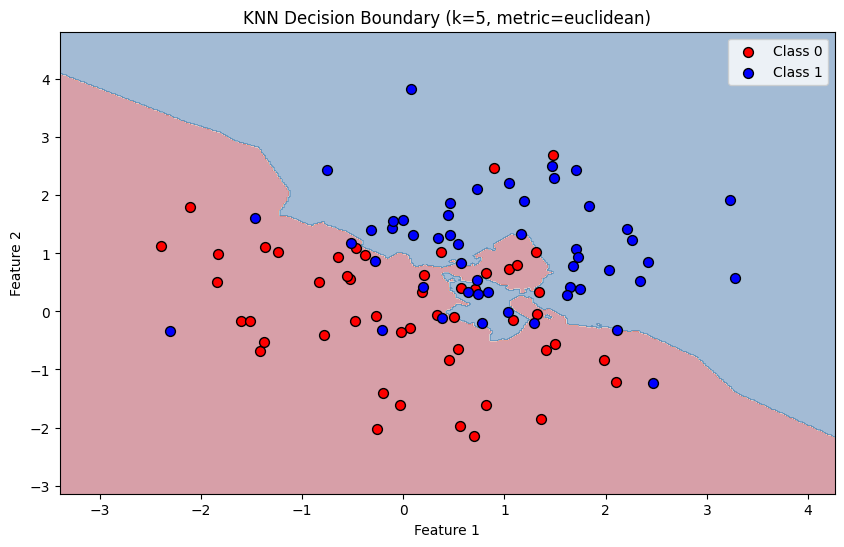

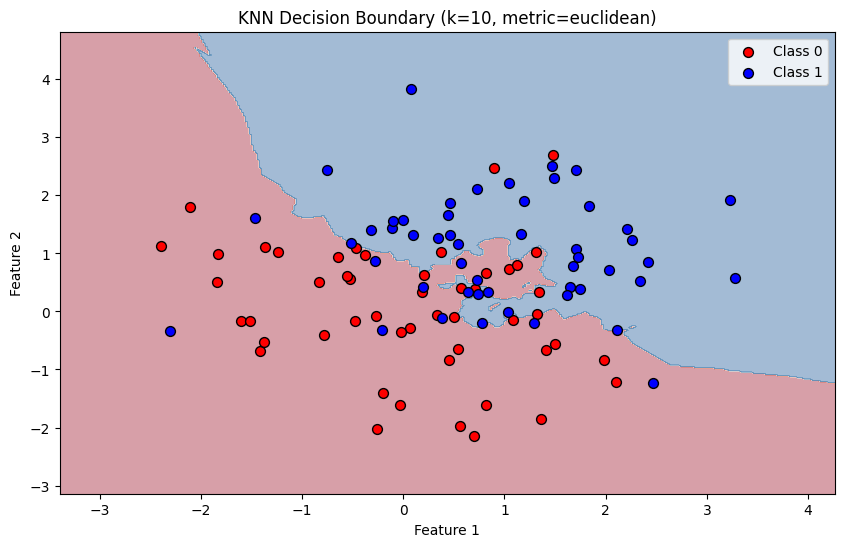

In [41]:
## HOMEWORK TASK 2.1
## Complete the function below to visualize KNN decision boundaries
## The function should create a mesh grid and predict class for each point

# HOMEWORK TASK 2.1 — KNN Decision Boundary Visualization

import scipy.stats as ss  # needed for generate_synth_data

def generate_synth_data(n=50):
    """Generate 2-class synthetic 2D data."""
    points = np.concatenate((ss.norm(0, 1).rvs((n, 2)), ss.norm(1, 1).rvs((n, 2))), axis=0)
    outcomes = np.concatenate((np.repeat(0, n), np.repeat(1, n)))
    return points, outcomes


def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.

    Parameters:
    X      : Training data (n_samples, 2)
    y      : Training labels
    k_value: Number of neighbors for KNN
    metric : Distance metric to use
    """
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Train KNN classifier
    knn_model = KNeighborsClassifier(n_neighbors=k_value, metric=metric)
    knn_model.fit(X, y)

    # Predict for each point in the mesh
    Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')

    # Overlay actual training points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red',  label='Class 0', edgecolors='k', s=50)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolors='k', s=50)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')
    plt.legend()
    plt.show()


# Generate synthetic data
n = 50
pts, tgts = generate_synth_data(n)

# Test with different k values
for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

**Discussion Questions:**
1. What happens to the decision boundary as K increases? Is it smoother or more irregular?
2. Which K value seems to generalize better without overfitting?
3. Try changing the metric to 'manhattan' - how does the boundary change?

---

### **Problem 3: Impact of Distance Metrics on High-Dimensional Data**

The "curse of dimensionality" affects distance metrics differently. Let's explore this phenomenon.

**Task 3.1:** Create a function that generates random high-dimensional data and compares how different distance metrics behave as dimensionality increases.

**Background:** In high dimensions, the ratio between the maximum and minimum distances between points tends to approach 1, making it harder to distinguish between near and far neighbors. This affects different metrics differently.

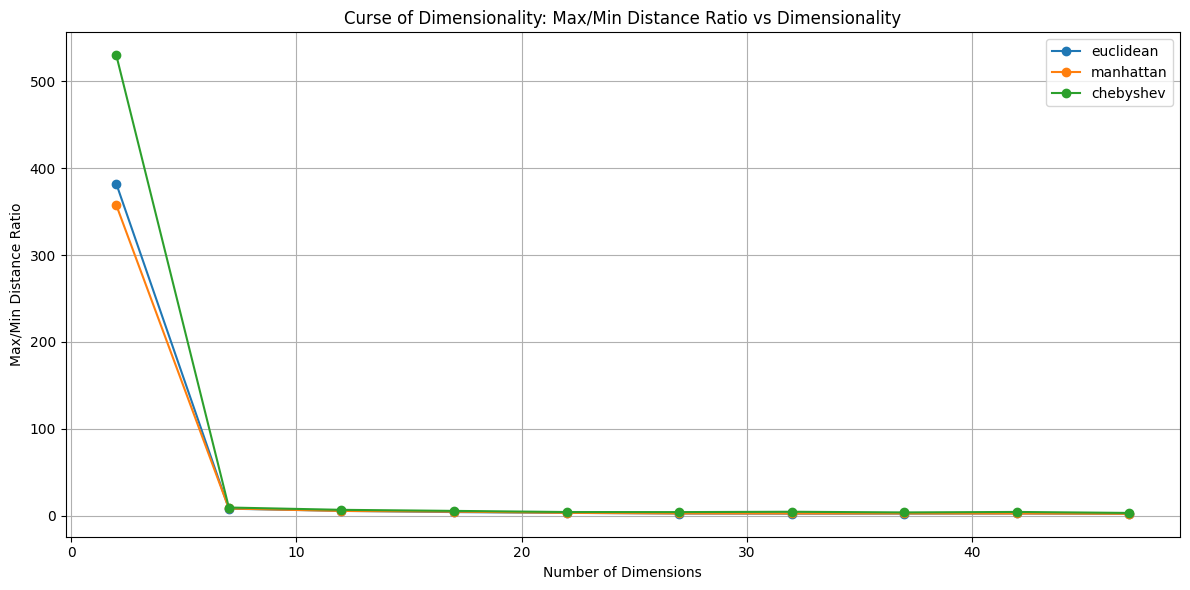

In [42]:
# HOMEWORK TASK 3.1 — Distance Metrics in High Dimensions

def analyze_distance_in_high_dims(max_dim=50, n_points=100):
    """
    Analyze how distance metrics behave in high dimensions by computing
    the ratio of max/min pairwise distances as dimensionality increases.
    A ratio close to 1 means distances are indistinguishable — bad for KNN.
    """
    dimensions = list(range(2, max_dim + 1, 5))
    results = {
        'euclidean': [],
        'manhattan': [],
        'chebyshev': []
    }

    for dim in dimensions:
        points = np.random.randn(n_points, dim)

        for metric in results.keys():
            dists = []
            for i in range(n_points):
                for j in range(i + 1, n_points):
                    if metric == 'euclidean':
                        d = distance.euclidean(points[i], points[j])
                    elif metric == 'manhattan':
                        d = distance.cityblock(points[i], points[j])
                    elif metric == 'chebyshev':
                        d = distance.chebyshev(points[i], points[j])
                    dists.append(d)

            dists = np.array(dists)
            ratio = dists.max() / (dists.min() + 1e-10)
            results[metric].append(ratio)

    # Plot
    plt.figure(figsize=(12, 6))
    for metric, ratios in results.items():
        plt.plot(dimensions, ratios, marker='o', label=metric)

    plt.xlabel('Number of Dimensions')
    plt.ylabel('Max/Min Distance Ratio')
    plt.title('Curse of Dimensionality: Max/Min Distance Ratio vs Dimensionality')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return results


np.random.seed(42)
results = analyze_distance_in_high_dims()

### Questions to Think About and Answer
1. In the section on Decision boundaries, you must have seen that we ran the KNN algorithm twice: first with the _weights_ set to 'uniform' and then set to 'distance'. Find out the difference between these two.  
2. What do you think could be the drawbacks of using KNN ?

Q1: Difference between weights='uniform' and weights='distance' in KNN
weights='uniform'weights='distance'How it votesEach of the K neighbours gets 1 equal voteEach neighbour votes with weight = 1/distanceCloser neighboursNo preferenceGet more influenceFarther neighboursSame vote as closestGet less influenceWhen to useWhen all neighbours are equally reliableWhen you believe closer = more relevant
Example: If 3 neighbours are at distances 0.1, 0.1, 5.0 — with uniform weights all 3 vote equally. With distance weights, the two close neighbours dominate heavily.

Q2: Drawbacks of KNN

Slow prediction: Must compute distance to every training point — O(n×d) per query. Very slow for large datasets.
High memory: Stores entire training dataset (no model compression like decision trees).
Curse of dimensionality: In high dimensions, all points become roughly equidistant, making "nearest" neighbour meaningless.
Sensitive to irrelevant features: All features contribute equally to distance unless you do feature selection/scaling.
Sensitive to scale: Features with large ranges dominate distances — normalization is essential.
Choosing K is tricky: Too small → overfits (noisy), too large → underfits (too smooth).
Imbalanced data: If one class has far more samples, it dominates the neighbourhood.


### Useful Resources for further reading
1. Interactive KNN visualization, with class boundaries: http://vision.stanford.edu/teaching/cs231n-demos/knn/  
